In [1]:
import pandas as pd

# Load the raw data
df = pd.read_csv('C:/Users/aniru/OneDrive/Desktop/Pokemon/data/raw/pokemon.csv')

# Basic shape and structure
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (1194, 13)

Columns: ['ID', 'Name', 'Total', 'HP', 'Attack', 'Defense', 'SpAtk', 'SpDef', 'Speed', 'Type1', 'Type2', 'Height', 'Weight']

Data types:
ID           int64
Name           str
Total        int64
HP           int64
Attack       int64
Defense      int64
SpAtk        int64
SpDef        int64
Speed        int64
Type1          str
Type2          str
Height     float64
Weight     float64
dtype: object


In [2]:
df.head()

,ID,Name,Total,HP,Attack,Defense,SpAtk,SpDef,Speed,Type1,Type2,Height,Weight
0,1,Bulbasaur,318,45,49,49,65,65,45,Grass,Poison,0.7,6.9
1,2,Ivysaur,405,60,62,63,80,80,60,Grass,Poison,1.0,13.0
2,3,Venusaur,525,80,82,83,100,100,80,Grass,Poison,2.0,100.0
3,3,Venusaur Mega Venusaur,625,80,100,123,122,120,80,Grass,Poison,2.4,155.5
4,4,Charmander,309,39,52,43,60,50,65,Fire,NaN,0.6,8.5


In [3]:
df.isnull().sum()

ID           0
Name         0
Total        0
HP           0
Attack       0
Defense      0
SpAtk        0
SpDef        0
Speed        0
Type1        0
Type2      542
Height       0
Weight       1
dtype: int64

In [4]:
from src.data_loader import load_pokemon
df = load_pokemon()

# See what's being flagged as legendary
legendaries = df[df['is_legendary']]
print(f"Total flagged: {len(legendaries)}")
print(f"\nBy form type:")
print(legendaries['form_type'].value_counts())
print(f"\nSample of legendaries:")
print(legendaries[['name', 'form_type', 'generation']].head(30))

Total flagged: 152

By form type:
form_type
Base         111
Alternate     32
Mega           6
Regional       3
Name: count, dtype: int64

Sample of legendaries:
                           name  form_type  generation
191                    Articuno       Base           1
192  Articuno Galarian Articuno   Regional           1
193                      Zapdos       Base           1
194      Zapdos Galarian Zapdos   Regional           1
195                     Moltres       Base           1
196    Moltres Galarian Moltres   Regional           1
200                      Mewtwo       Base           1
201        Mewtwo Mega Mewtwo X       Mega           1
202        Mewtwo Mega Mewtwo Y       Mega           1
203                         Mew       Base           1
306                      Raikou       Base           2
307                       Entei       Base           2
308                     Suicune       Base           2
313                       Lugia       Base           2
315          

In [5]:
# Look for any name containing 'max', 'giga', or 'dynamax'
suspicious = df[df['name'].str.lower().str.contains('max|giga|dynamax', regex=True)]
print(suspicious[['name', 'form_type']].head(20))

                     name  form_type
596             Regigigas       Base
639              Gigalith       Base
1058  Eternatus Eternamax  Alternate


In [6]:
# Check for any "form-like" words in Base-labeled rows
base_df = df[df['form_type'] == 'Base']
form_keywords = ['form', 'forme', 'primal', 'origin', 'therian', 'incarnate',
                 'black', 'white', 'dawn', 'dusk', 'ultra', 'crowned', 'eternamax']
for kw in form_keywords:
    matches = base_df[base_df['name'].str.lower().str.contains(kw)]
    if len(matches) > 0:
        print(f"'{kw}' found in {len(matches)} 'Base' rows:")
        print(matches['name'].tolist()[:5])
        print()

'form' found in 18 'Base' rows:
['Castform', 'Giratina Altered Forme', 'Basculin Red-Striped Form', 'Keldeo Ordinary Form', 'Keldeo Resolute Form']

'forme' found in 3 'Base' rows:
['Giratina Altered Forme', 'Aegislash Shield Forme', 'Aegislash Blade Forme']

'dusk' found in 2 'Base' rows:
['Duskull', 'Dusknoir']



In [7]:
from src.data_loader import load_pokemon
df = load_pokemon()

print(f"Form types:\n{df['form_type'].value_counts()}")
print(f"\nTotal 'Base' rows: {(df['form_type'] == 'Base').sum()}")

# Re-run the alternate form check — should find near-zero now
base_df = df[df['form_type'] == 'Base']
form_keywords = ['forme', 'primal', 'origin', 'therian', 'incarnate',
                 'crowned', 'eternamax']
print("\nRemaining alternate forms in 'Base':")
for kw in form_keywords:
    matches = base_df[base_df['name'].str.lower().str.contains(kw)]
    if len(matches) > 0:
        print(f"  '{kw}': {matches['name'].tolist()}")

Form types:
form_type
Base         1026
Alternate      64
Regional       55
Mega           49
Name: count, dtype: int64

Total 'Base' rows: 1026

Remaining alternate forms in 'Base':
  'forme': ['Giratina Altered Forme', 'Aegislash Shield Forme', 'Aegislash Blade Forme']


In [8]:
from src.data_loader import load_pokemon
df = load_pokemon()

print(df['form_type'].value_counts())
print()
print("Giratina rows:")
print(df[df['name'].str.contains('Giratina')][['name', 'form_type']])
print()
print("Aegislash rows:")
print(df[df['name'].str.contains('Aegislash')][['name', 'form_type']])

form_type
Base         1026
Alternate      64
Regional       55
Mega           49
Name: count, dtype: int64

Giratina rows:
                       name  form_type
597  Giratina Altered Forme       Base
598   Giratina Origin Forme  Alternate

Aegislash rows:
                       name form_type
816  Aegislash Shield Forme      Base
817   Aegislash Blade Forme      Base


In [9]:
import importlib
from src import data_loader
importlib.reload(data_loader)  # Forces Python to re-read the file

# Check #1: Is "blade forme" in our keywords list?
print("Keywords containing 'blade':")
print([kw for kw in data_loader._get_form_type.__code__.co_consts if isinstance(kw, str) and 'blade' in kw.lower()])

# Check #2: Run the classifier directly on the exact name
test_name = "Aegislash Blade Forme"
print(f"\n_get_form_type('{test_name}') = {data_loader._get_form_type(test_name)}")

# Check #3: Look at the actual string in the dataframe
df = data_loader.load_pokemon()
aegislash_blade = df[df['name'].str.contains('Blade')]
print(f"\nRaw name bytes: {aegislash_blade['name'].iloc[0].encode('utf-8')}")
print(f"Form type: {aegislash_blade['form_type'].iloc[0]}")

Keywords containing 'blade':
[]

_get_form_type('Aegislash Blade Forme') = Base

Raw name bytes: b'Aegislash Blade Forme'
Form type: Base


In [10]:
import importlib
from src import data_loader
importlib.reload(data_loader)

# Quick direct test
print(data_loader._get_form_type("Aegislash Blade Forme"))
# Should print: Alternate

df = data_loader.load_pokemon()
print(df[df['name'].str.contains('Aegislash')][['name', 'form_type']])

Alternate
                       name  form_type
816  Aegislash Shield Forme       Base
817   Aegislash Blade Forme  Alternate


In [1]:
from src.data_loader import save_processed, load_processed

path = save_processed()
print(f"Saved to {path}")

df = load_processed()
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")

Saved to C:\Users\aniru\OneDrive\Desktop\Pokemon\data\processed\pokemon_clean.parquet
Loaded 1194 rows, 16 columns


In [1]:
from src.data_loader import save_featured, load_featured

path = save_featured()
print(f"Saved to {path}")

df = load_featured()
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"\nFirst 5 Pokémon with new features:")
print(df[['name', 'bst', 'offensive_total', 'defensive_total', 
         'stat_profile', 'speed_tier', 'num_types']].head())

Saved to C:\Users\aniru\OneDrive\Desktop\Pokemon\data\processed\pokemon_featured.parquet
Loaded 1194 rows, 78 columns

First 5 Pokémon with new features:
                     name  bst  offensive_total  defensive_total  \
0               Bulbasaur  318              159              159   
1                 Ivysaur  405              202              203   
2                Venusaur  525              262              263   
3  Venusaur Mega Venusaur  625              302              323   
4              Charmander  309              177              132   

      stat_profile speed_tier  num_types  
0         Balanced       Slow          2  
1         Balanced     Medium          2  
2         Balanced     Medium          2  
3         Balanced     Medium          2  
4  Special Sweeper     Medium          1  


In [3]:
from src.data_loader import save_processed, save_featured, load_featured

# Regenerate both parquet files with the new column
save_processed()
save_featured()

df = load_featured()

# Sanity check the new column
print("Legendary category counts:")
print(df['legendary_category'].value_counts())
print()

# Cross-tab: how does category correlate with is_legendary?
print("\nCross-tab (should show 'None' only in is_legendary=False, everything else in True):")
print(pd.crosstab(df['legendary_category'], df['is_legendary']))

Legendary category counts:
legendary_category
None           1042
Traditional      92
Mythical         33
Paradox          16
Ultra Beast      11
Name: count, dtype: int64


Cross-tab (should show 'None' only in is_legendary=False, everything else in True):
is_legendary        False  True 
legendary_category              
Mythical                0     33
None                 1042      0
Paradox                 0     16
Traditional             0     92
Ultra Beast             0     11


In [5]:
from src.data_loader import load_raw_pokemon
df_raw = load_raw_pokemon()
print(df_raw.columns.tolist())
print(df_raw.head(2))

['pokedex_id', 'name', 'bst', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'type_1', 'type_2', 'height', 'weight']
   pokedex_id       name  bst  hp  attack  defense  sp_attack  sp_defense  \
0           1  Bulbasaur  318  45      49       49         65          65   
1           2    Ivysaur  405  60      62       63         80          80   

   speed type_1  type_2  height  weight  
0     45  Grass  Poison     0.7     6.9  
1     60  Grass  Poison     1.0    13.0  


In [2]:
import pandas as pd
df_tiers = pd.read_csv('C:/Users/aniru/OneDrive/Desktop/Pokemon/data/raw/smogon.csv')
print(f"Shape: {df_tiers.shape}")
print(f"\nColumns: {df_tiers.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_tiers.head())
print(f"\nTier value counts:")
print(df_tiers.iloc[:, -1].value_counts())  # assumes tier is last column

Shape: (499, 15)

Columns: ['X.', 'Name', 'Type.1', 'Type.2', 'Total', 'HP', 'Attack', 'Defense', 'Sp..Atk', 'Sp..Def', 'Speed', 'Generation', 'Legendary', 'Mega', 'Tier']

First few rows:
    X.             Name   Type.1    Type.2  Total   HP  Attack  Defense  \
0  384    Mega Rayquaza   Dragon    Flying    780  105     180      100   
1   94      Mega Gengar    Ghost    Poison    600   60      65       80   
2  115  Mega Kangaskhan   Normal       NaN    590  105     125      100   
3  150           Mewtwo  Psychic       NaN    680  106     110       90   
4  150    Mega Mewtwo X  Psychic  Fighting    780  106     190      100   

   Sp..Atk  Sp..Def  Speed  Generation  Legendary   Mega  Tier  
0      180      100    115           3       True   True    AG  
1      170       95    130           1      False   True  Uber  
2       60      100    100           1      False   True  Uber  
3      154       90    130           1       True  False  Uber  
4      154      100    130         

In [4]:
from src.data_loader import load_pokemon_with_tiers, load_tiers

# First check the tiers dataset itself
df_tiers = load_tiers()
print(f"Tiers dataset: {len(df_tiers)} rows")
print(f"Viable: {df_tiers['is_viable'].sum()} | Non-viable: {(~df_tiers['is_viable']).sum()}")
print(f"\nTier distribution:\n{df_tiers['tier'].value_counts()}")

print("\n--- Joined Dataset ---")
df = load_pokemon_with_tiers()
print(f"Total rows: {len(df)}")
print(f"\nTier distribution in joined data:\n{df['tier'].value_counts()}")

# Safe counts that handle NaN correctly
viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"\nViable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

Tiers dataset: 499 rows
Viable: 179 | Non-viable: 320

Tier distribution:
tier
PU      179
UU       65
OU       57
NU       57
RU       54
Uber     39
BL2      21
BL       17
BL4       8
AG        1
BL3       1
Name: count, dtype: int64

--- Joined Dataset ---
Total rows: 1194

Tier distribution in joined data:
tier
Untiered    693
PU          193
NU           68
UU           63
RU           60
OU           44
Uber         26
BL2          23
BL           12
BL4          10
BL3           2
Name: count, dtype: int64

Viable: 145 | Non-viable: 356 | Untiered: 693


In [5]:
# Check: do any well-known competitive Pokémon end up Untiered?
# These should all have tiers — if any show "Untiered" we have a name mismatch
known_competitive = [
    "Garchomp", "Toxapex", "Corviknight", "Dragapult",
    "Landorus", "Clefable", "Volcarona", "Heatran"
]

check = df[df['name'].isin(known_competitive)][['name', 'tier', 'is_viable']]
print("Known competitive Pokémon — tier check:")
print(check)

# Check: how many base-form non-legendary Pokémon got tiered?
base_tiered = df[
    (df['form_type'] == 'Base') &
    (df['legendary_category'] == 'None') &
    (df['tier'] != 'Untiered')
]
print(f"\nBase-form non-legendary Pokémon with tiers: {len(base_tiered)}")
print(f"Out of total base-form non-legendary: {len(df[(df['form_type'] == 'Base') & (df['legendary_category'] == 'None')])}")

Known competitive Pokémon — tier check:
             name      tier is_viable
47       Clefable        OU      True
544      Garchomp        OU      True
595       Heatran        OU      True
763     Volcarona        BL      True
905       Toxapex  Untiered       NaN
984   Corviknight  Untiered       NaN
1052    Dragapult  Untiered       NaN

Base-form non-legendary Pokémon with tiers: 366
Out of total base-form non-legendary: 914


In [6]:
# Check what name_key our main dataset generates for these
df_check = df[df['name'].isin(['Toxapex', 'Corviknight', 'Dragapult'])][['name', 'name_key', 'tier']]
print("Main dataset name keys:")
print(df_check)

# Check what name_key the tiers dataset generates for these
from src.data_loader import load_tiers
df_tiers = load_tiers()
tiers_check = df_tiers[df_tiers['name'].str.contains('Toxapex|Corviknight|Dragapult', case=False)]
print("\nSmogon dataset entries:")
print(tiers_check)

Main dataset name keys:
             name     name_key      tier
905       Toxapex      toxapex  Untiered
984   Corviknight  corviknight  Untiered
1052    Dragapult    dragapult  Untiered

Smogon dataset entries:
Empty DataFrame
Columns: [name, name_key, tier, is_viable]
Index: []


In [7]:
# Check for duplicate name_keys in the tiers dataset
print("Duplicate name_keys in tiers dataset:")
dupes = df_tiers[df_tiers['name_key'].duplicated(keep=False)]
print(dupes[['name', 'name_key', 'tier']].sort_values('name_key'))

Duplicate name_keys in tiers dataset:
                 name name_key  tier
0       Mega Rayquaza             AG
1         Mega Gengar           Uber
2     Mega Kangaskhan           Uber
4       Mega Mewtwo X           Uber
5       Mega Mewtwo Y           Uber
9       Mega Blaziken           Uber
10       Mega Sableye           Uber
11        Mega Mawile           Uber
12     Mega Salamence           Uber
16       Mega Lucario           Uber
35     Primal Groudon           Uber
36      Primal Kyogre           Uber
40      Mega Venusaur             OU
41   Mega Charizard X             OU
42   Mega Charizard Y             OU
46       Mega Slowbro             OU
50        Mega Pinsir             OU
56        Mega Scizor             OU
57     Mega Heracross             OU
61     Mega Tyranitar             OU
62     Mega Gardevoir             OU
64      Mega Medicham             OU
65     Mega Manectric             OU
66     Mega Metagross             OU
68        Mega Latias             OU


In [3]:
from src.data_loader import load_pokemon_with_tiers, load_tiers

df_tiers = load_tiers()
print(f"Tiers dataset after cleaning: {len(df_tiers)} rows")
print(f"Viable: {(df_tiers['is_viable'] == True).sum()} | Non-viable: {(df_tiers['is_viable'] == False).sum()}")

# Check for any empty name_keys
print(f"Empty name_keys: {(df_tiers['name_key'] == '').sum()}")

# Check duplicates
print(f"Duplicate name_keys: {df_tiers['name_key'].duplicated().sum()}")

print("\n--- Joined Dataset ---")
df = load_pokemon_with_tiers()

viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"Viable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

print(f"\nTier distribution:\n{df['tier'].value_counts()}")

# Re-check the known competitive Pokémon
known_competitive = [
    "Garchomp", "Toxapex", "Corviknight", "Dragapult",
    "Clefable", "Volcarona", "Heatran", "Landorus"
]
check = df[df['name'].isin(known_competitive)][['name', 'tier', 'is_viable']]
print(f"\nKnown competitive Pokémon check:\n{check}")

Tiers dataset after cleaning: 448 rows
Viable: 136 | Non-viable: 312
Empty name_keys: 0
Duplicate name_keys: 0

--- Joined Dataset ---
Viable: 158 | Non-viable: 358 | Untiered: 678

Tier distribution:
tier
Untiered    678
PU          195
NU           68
UU           65
RU           60
OU           46
Uber         35
BL2          23
BL           12
BL4          10
BL3           2
Name: count, dtype: int64

Known competitive Pokémon check:
             name      tier is_viable
47       Clefable        OU      True
544      Garchomp        OU      True
595       Heatran        OU      True
763     Volcarona        BL      True
905       Toxapex  Untiered       NaN
984   Corviknight  Untiered       NaN
1052    Dragapult  Untiered       NaN


In [4]:
# Find any Pokémon in the joined data that matched more than once
# (would show as duplicate rows with same name but different tiers)
dupes_in_join = df[df.duplicated(subset='name', keep=False) & (df['tier'] != 'Untiered')]
print(f"Rows with duplicate name + tier assignments: {len(dupes_in_join)}")
print(dupes_in_join[['name', 'name_key', 'tier']].head(20))

# Also check: are any non-base forms getting tier labels?
non_base_tiered = df[
    (df['form_type'] != 'Base') &
    (df['tier'] != 'Untiered')
][['name', 'form_type', 'tier']]
print(f"\nNon-base forms with tier labels: {len(non_base_tiered)}")
print(non_base_tiered.head(20))

Rows with duplicate name + tier assignments: 0
Empty DataFrame
Columns: [name, name_key, tier]
Index: []

Non-base forms with tier labels: 105
                               name form_type tier
3            Venusaur Mega Venusaur      Mega   RU
7        Charizard Mega Charizard X      Mega   NU
8        Charizard Mega Charizard Y      Mega   NU
12         Blastoise Mega Blastoise      Mega   RU
19           Beedrill Mega Beedrill      Mega   PU
23             Pidgeot Mega Pidgeot      Mega   PU
27         Raticate Alolan Raticate  Regional   PU
35             Raichu Alolan Raichu  Regional   PU
39       Sandslash Alolan Sandslash  Regional   NU
51       Ninetales Alolan Ninetales  Regional   PU
66           Dugtrio Alolan Dugtrio  Regional   OU
71           Persian Alolan Persian  Regional   PU
79        Arcanine Hisuian Arcanine  Regional   UU
86           Alakazam Mega Alakazam      Mega   BL
100              Golem Alolan Golem  Regional   PU
104      Rapidash Galarian Rapidash  Regi

In [3]:
from src.data_loader import load_pokemon_with_tiers

df = load_pokemon_with_tiers()

# Core counts
viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"Viable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

# Tier distribution
print(f"\nTier distribution:\n{df['tier'].value_counts()}")

# Non-base forms should all be Untiered now
non_base_tiered = df[
    (df['form_type'] != 'Base') &
    (df['tier'] != 'Untiered')
]
print(f"\nNon-base forms with tier labels (should be 0): {len(non_base_tiered)}")

# Known competitive check
known = ["Garchomp", "Clefable", "Heatran", "Volcarona",
         "Toxapex", "Corviknight", "Dragapult"]
print(f"\nKnown competitive Pokémon:")
print(df[df['name'].isin(known)][['name', 'form_type', 'tier', 'is_viable']])

Viable: 116 | Non-viable: 295 | Untiered: 783

Tier distribution:
tier
Untiered    783
PU          166
NU           56
UU           53
RU           47
OU           34
Uber         19
BL2          17
BL           10
BL4           8
BL3           1
Name: count, dtype: int64

Non-base forms with tier labels (should be 0): 0

Known competitive Pokémon:
             name form_type      tier is_viable
47       Clefable      Base        OU      True
544      Garchomp      Base        OU      True
595       Heatran      Base        OU      True
763     Volcarona      Base        BL      True
905       Toxapex      Base  Untiered       NaN
984   Corviknight      Base  Untiered       NaN
1052    Dragapult      Base  Untiered       NaN


In [4]:
from src.data_loader import load_tiers, load_pokemon_with_tiers

df = load_pokemon_with_tiers()
df_tiers = load_tiers()

# Find tiers dataset entries that didn't match anything in the main dataset
# by checking which name_keys from tiers are absent from the joined result
matched_keys = set(df[df['tier'] != 'Untiered']['name_key'])
tiers_keys = set(df_tiers['name_key'])

unmatched = df_tiers[df_tiers['name_key'].isin(tiers_keys - matched_keys)]
print(f"Tiers dataset entries with no match in main dataset: {len(unmatched)}")
print(unmatched[['name', 'name_key', 'tier']].sort_values('tier'))

Tiers dataset entries with no match in main dataset: 37
                name         name_key  tier
112      Thundurus-T      thundurus-t    BL
113          Zygarde          zygarde    BL
199          Shaymin          shaymin   BL2
91            Keldeo           keldeo    OU
92          Kyurem-B         kyurem-b    OU
93        Landorus-T       landorus-t    OU
94        Tornadus-T       tornadus-t    OU
95           Rotom-W          rotom-w    OU
96         Thundurus        thundurus    OU
459         Basculin         basculin    PU
488        Gourgeist        gourgeist    PU
489  Gourgeist-Small  gourgeist-small    PU
490  Gourgeist-Large  gourgeist-large    PU
491  Gourgeist-Super  gourgeist-super    PU
492       Meowstic-M       meowstic-m    PU
493       Meowstic-F       meowstic-f    PU
494          Rotom-F          rotom-f    PU
495          Rotom-S          rotom-s    PU
496   Wormadam-Plant   wormadam-plant    PU
497   Wormadam-Sandy   wormadam-sandy    PU
498   Wormadam-Trash

In [5]:
# Check what our main dataset calls these problematic Pokémon
problem_species = [
    'Kyurem', 'Landorus', 'Tornadus', 'Thundurus', 'Rotom',
    'Deoxys', 'Giratina', 'Hoopa', 'Shaymin', 'Meloetta',
    'Keldeo', 'Zygarde', 'Darmanitan', 'Basculin',
    'Gourgeist', 'Meowstic', 'Wormadam'
]

for species in problem_species:
    matches = df[df['name'].str.contains(species, case=False)][['name', 'name_key', 'form_type', 'tier']]
    if len(matches) > 0:
        print(f"\n{species}:")
        print(matches.to_string())


Kyurem:
                    name name_key  form_type      tier
775               Kyurem   kyurem       Base       BL2
776  Kyurem White Kyurem   kyurem  Alternate  Untiered
777  Kyurem Black Kyurem   kyurem  Alternate  Untiered

Landorus:
                         name  name_key  form_type      tier
773  Landorus Incarnate Forme  landorus  Alternate  Untiered
774    Landorus Therian Forme  landorus  Alternate  Untiered

Tornadus:
                         name  name_key  form_type      tier
767    Tornadus Therian Forme  tornadus  Alternate  Untiered
768  Tornadus Incarnate Forme  tornadus  Alternate  Untiered

Thundurus:
                          name   name_key  form_type      tier
769    Thundurus Therian Forme  thundurus  Alternate  Untiered
770  Thundurus Incarnate Forme  thundurus  Alternate  Untiered

Rotom:
                  name           name_key form_type      tier
582    Rotom Fan Rotom    rotom-fan-rotom      Base  Untiered
583  Rotom Frost Rotom  rotom-frost-rotom      Bas

In [3]:
from src.data_loader import load_pokemon_with_tiers, load_tiers

df_tiers = load_tiers()
df = load_pokemon_with_tiers()

# Core counts
viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"Viable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

# Tier distribution — should now be close to source dataset counts
print(f"\nTier distribution:\n{df['tier'].value_counts()}")

# Non-base/non-mapped forms should still be Untiered
non_base_tiered = df[
    (df['form_type'] != 'Base') &
    (~df['name'].isin(list(__import__('src.data_loader', fromlist=['MANUAL_NAME_MAP']).MANUAL_NAME_MAP.keys()))) &
    (df['tier'] != 'Untiered')
]
print(f"\nUnexpected non-base tiers (should be 0): {len(non_base_tiered)}")

# Spot check the previously failing Pokémon
spot_check = [
    "Rotom Wash Rotom", "Landorus Therian Forme", "Deoxys Attack Forme",
    "Kyurem Black Kyurem", "Garchomp", "Clefable", "Giratina Altered Forme"
]
print(f"\nSpot check:")
print(df[df['name'].isin(spot_check)][['name', 'form_type', 'tier', 'is_viable']])

Viable: 136 | Non-viable: 305 | Untiered: 753

Tier distribution:
tier
Untiered    753
PU          172
NU           56
UU           56
RU           50
OU           41
Uber         27
BL2          18
BL           12
BL4           8
BL3           1
Name: count, dtype: int64

Unexpected non-base tiers (should be 0): 0

Spot check:
                       name  form_type  tier is_viable
47                 Clefable       Base    OU      True
479     Deoxys Attack Forme  Alternate  Uber      True
545                Garchomp       Base    OU      True
583        Rotom Wash Rotom       Base    OU      True
597  Giratina Altered Forme       Base  Uber      True
774  Landorus Therian Forme  Alternate    OU      True
775     Kyurem Black Kyurem  Alternate    OU      True


In [4]:
from src.data_loader import load_tiers, load_pokemon_with_tiers, MANUAL_NAME_MAP

df = load_pokemon_with_tiers()
df_tiers = load_tiers()

# Find tiers dataset entries still not matching anything
matched_keys = set(df[df['tier'] != 'Untiered']['name_key'])
tiers_keys = set(df_tiers['name_key'])

unmatched = df_tiers[df_tiers['name_key'].isin(tiers_keys - matched_keys)]
print(f"Still unmatched: {len(unmatched)}")
print(unmatched[['name', 'name_key', 'tier']].sort_values('tier'))

Still unmatched: 8
                name         name_key  tier
489  Gourgeist-Small  gourgeist-small    PU
490  Gourgeist-Large  gourgeist-large    PU
491  Gourgeist-Super  gourgeist-super    PU
496   Wormadam-Plant   wormadam-plant    PU
497   Wormadam-Sandy   wormadam-sandy    PU
498   Wormadam-Trash   wormadam-trash    PU
252       Meloetta-P       meloetta-p    RU
32        Giratina-O       giratina-o  Uber


In [3]:
from src.data_loader import load_tiers, load_pokemon_with_tiers, MANUAL_NAME_MAP

df = load_pokemon_with_tiers()
df_tiers = load_tiers()

# Remaining unmatched
matched_keys = set(df[df['tier'] != 'Untiered']['name_key'])
tiers_keys = set(df_tiers['name_key'])
unmatched = df_tiers[df_tiers['name_key'].isin(tiers_keys - matched_keys)]
print(f"Still unmatched: {len(unmatched)}")
if len(unmatched) > 0:
    print(unmatched[['name', 'name_key', 'tier']])

# Core counts
viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"\nViable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

# Tier distribution
print(f"\nTier distribution:\n{df['tier'].value_counts()}")

# Final spot check
spot_check = [
    "Giratina Origin Forme", "Meloetta Pirouette Forme",
    "Wormadam Plant Cloak", "Rotom Wash Rotom",
    "Landorus Therian Forme", "Garchomp", "Toxapex"
]
print(f"\nFinal spot check:")
print(df[df['name'].isin(spot_check)][['name', 'form_type', 'tier', 'is_viable']])

Still unmatched: 0

Viable: 137 | Non-viable: 312 | Untiered: 745

Tier distribution:
tier
Untiered    745
PU          178
NU           56
UU           56
RU           51
OU           41
Uber         28
BL2          18
BL           12
BL4           8
BL3           1
Name: count, dtype: int64

Final spot check:
                         name  form_type      tier is_viable
510      Wormadam Plant Cloak  Alternate        PU     False
545                  Garchomp       Base        OU      True
584          Rotom Wash Rotom       Base        OU      True
597     Giratina Origin Forme  Alternate      Uber      True
773    Landorus Therian Forme  Alternate        OU      True
781  Meloetta Pirouette Forme  Alternate        RU     False
905                   Toxapex       Base  Untiered       NaN


In [4]:
from src.data_loader import load_tiers, load_pokemon_with_tiers, MANUAL_NAME_MAP

df = load_pokemon_with_tiers()
df_tiers = load_tiers()

# Compare source tier counts vs joined tier counts side by side
source_counts = df_tiers['tier'].value_counts().rename('source')
joined_counts = df[df['tier'] != 'Untiered']['tier'].value_counts().rename('joined')
comparison = pd.concat([source_counts, joined_counts], axis=1).fillna(0).astype(int)
comparison['diff'] = comparison['joined'] - comparison['source']
print("Tier count comparison (source vs joined):")
print(comparison)

# Find which specific Pokémon from the tiers dataset are NOT showing up tiered
# in the joined result despite name_key matching
tiers_keys_to_names = df_tiers.set_index('name_key')['name'].to_dict()
matched_keys = set(df[df['tier'] != 'Untiered']['name_key'])
tiers_keys = set(df_tiers['name_key'])

# These matched earlier (unmatched=0) but may not be in joined result
missing_from_join = tiers_keys - matched_keys
print(f"\nKeys in tiers dataset not appearing in joined result: {len(missing_from_join)}")
for key in sorted(missing_from_join):
    print(f"  {key} -> {tiers_keys_to_names.get(key, '?')} ({df_tiers[df_tiers['name_key']==key]['tier'].values[0]})")

Tier count comparison (source vs joined):
      source  joined  diff
tier                      
PU       178     178     0
UU        56      56     0
NU        56      56     0
RU        51      51     0
OU        40      41     1
Uber      28      28     0
BL2       18      18     0
BL        12      12     0
BL4        8       8     0
BL3        1       1     0

Keys in tiers dataset not appearing in joined result: 0


In [5]:
from src.data_loader import load_pokemon_with_tiers
import pandas as pd
from pathlib import Path

df = load_pokemon_with_tiers()

# Save to processed/
output_path = Path('../data/processed/pokemon_with_tiers.parquet')
df.to_parquet(output_path, index=False)
print(f"Saved to {output_path}")
print(f"Shape: {df.shape}")
print(f"\nViable: {(df['is_viable'] == True).sum()}")
print(f"Non-viable: {(df['is_viable'] == False).sum()}")
print(f"Untiered: {df['is_viable'].isna().sum()}")

Saved to ..\data\processed\pokemon_with_tiers.parquet
Shape: (1194, 82)

Viable: 137
Non-viable: 312
Untiered: 745


In [3]:
from src.data_loader import load_tiered
df = load_tiered()
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"Columns: {df.columns.tolist()[-5:]}")  # last 5 to confirm tier columns present

Loaded 1194 rows, 82 columns
Columns: ['type_2_Steel', 'type_2_Water', 'name_key', 'tier', 'is_viable']


In [4]:
from src.data_loader import load_tiered
import pandas as pd
import numpy as np

df = load_tiered()

# Columns to explicitly exclude
EXCLUDE_COLS = {
    'name', 'name_key', 'pokedex_id',
    'type_1', 'type_2',
    'form_type', 'legendary_category',
    'tier', 'is_viable',
    'speed_tier', 'stat_profile',
    'generation',
}

# Build feature list from remaining columns
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

print(f"Total features: {len(FEATURE_COLS)}")
print(f"\nFeature list:")
for col in FEATURE_COLS:
    print(f"  {col}")

Total features: 70

Feature list:
  bst
  hp
  attack
  defense
  sp_attack
  sp_defense
  speed
  height
  weight
  is_legendary
  offensive_total
  defensive_total
  physical_bias
  defensive_bias
  num_types
  has_type_Normal
  has_type_Fire
  has_type_Water
  has_type_Electric
  has_type_Grass
  has_type_Ice
  has_type_Fighting
  has_type_Poison
  has_type_Ground
  has_type_Flying
  has_type_Psychic
  has_type_Bug
  has_type_Rock
  has_type_Ghost
  has_type_Dragon
  has_type_Dark
  has_type_Steel
  has_type_Fairy
  type_1_Bug
  type_1_Dark
  type_1_Dragon
  type_1_Electric
  type_1_Fairy
  type_1_Fighting
  type_1_Fire
  type_1_Flying
  type_1_Ghost
  type_1_Grass
  type_1_Ground
  type_1_Ice
  type_1_Normal
  type_1_Poison
  type_1_Psychic
  type_1_Rock
  type_1_Steel
  type_1_Water
  type_2_Bug
  type_2_Dark
  type_2_Dragon
  type_2_Electric
  type_2_Fairy
  type_2_Fighting
  type_2_Fire
  type_2_Flying
  type_2_Ghost
  type_2_Grass
  type_2_Ground
  type_2_Ice
  type_2_None
  ty

In [5]:
# Filter to tiered Pokémon only (drop Untiered/NaN)
df_model = df[df['is_viable'].notna()].copy()

print(f"Modelling dataset: {len(df_model)} rows")
print(f"Viable (1): {(df_model['is_viable'] == True).sum()}")
print(f"Non-viable (0): {(df_model['is_viable'] == False).sum()}")
print(f"Class balance: {(df_model['is_viable'] == True).mean():.1%} viable")

# Encode label as int
df_model['is_viable'] = df_model['is_viable'].astype(int)

# Feature matrix and label vector
X = df_model[FEATURE_COLS]
y = df_model['is_viable']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nAny nulls in X: {X.isnull().sum().sum()}")

Modelling dataset: 449 rows
Viable (1): 137
Non-viable (0): 312
Class balance: 30.5% viable

X shape: (449, 70)
y shape: (449,)

Any nulls in X: 0


In [6]:
# Generation-based split
train_mask = df_model['generation'] <= 7
test_mask = df_model['generation'] >= 8

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Train set (Gens 1-7): {len(X_train)} rows")
print(f"  Viable: {y_train.sum()} | Non-viable: {(y_train == 0).sum()}")
print(f"  Class balance: {y_train.mean():.1%} viable")
print(f"\nTest set (Gens 8-9): {len(X_test)} rows")
print(f"  Viable: {y_test.sum()} | Non-viable: {(y_test == 0).sum()}")
print(f"  Class balance: {y_test.mean():.1%} viable")

Train set (Gens 1-7): 449 rows
  Viable: 137 | Non-viable: 312
  Class balance: 30.5% viable

Test set (Gens 8-9): 0 rows
  Viable: 0 | Non-viable: 0
  Class balance: nan% viable


In [7]:
# Replace 'your_file.csv' with whatever name showed up above
df_new = pd.read_csv('C:/Users/aniru/OneDrive/Desktop/Pokemon/data/raw/pokemon_data.csv')

print(f"Shape: {df_new.shape}")
print(f"\nColumns: {df_new.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_new.head())
print(f"\nUnique values in tier/rank column (if exists):")

# Try to find a tier-like column automatically
tier_candidates = [c for c in df_new.columns if any(
    kw in c.lower() for kw in ['tier', 'rank', 'class', 'level']
)]
print(f"Tier-like columns found: {tier_candidates}")
for col in tier_candidates:
    print(f"\n{col} value counts:")
    print(df_new[col].value_counts())

Shape: (738, 71)

Columns: ['name', 'hp', 'atk', 'def', 'spa', 'spd', 'spe', 'weight', 'height', 'formats', 'generation', 'format codes', 'Weaknesses', 'Strong Weaknesses', 'Resists', 'Strong Resists', 'Immune', 'STAB', 'Resistance Index', 'Entry Hazards', 'Hazard Removal', 'Removal Deterrent', 'Cleric', 'Pivot', 'Item Removal', 'Setup', 'Priority', 'HP Drain', 'HP Recovery', 'Weather Set', 'Weather Gimmick', 'Physical Cutoff 1', 'Physical Cutoff 2', 'Physical Cutoff 3', 'Physical Cutoff 4', 'Physical Cutoff 5', 'Physical Cutoff 6', 'Physical Coverage 1', 'Physical Coverage 2', 'Physical Coverage 3', 'Physical Coverage 4', 'Special Cutoff 1', 'Special Cutoff 2', 'Special Cutoff 3', 'Special Cutoff 4', 'Special Cutoff 5', 'Special Cutoff 6', 'Special Cutoff 7', 'Special Coverage 1', 'Special Coverage 2', 'Special Coverage 3', 'Special Coverage 4', 'Special Coverage 5', 'Special Coverage 6', 'Special Coverage 7', 'Special Coverage 8', 'Special Coverage 9', 'Special Coverage 10', 'Misc St

In [8]:
# Check Gen 8/9 coverage
print("Generation distribution:")
print(df_new['generation'].value_counts().sort_index())

# Check the specific Pokémon that were missing from our old dataset
missing_before = ['Toxapex', 'Corviknight', 'Dragapult', 'Cinderace', 'Miraidon', 'Koraidon']
print("\nPreviously missing Pokémon:")
print(df_new[df_new['name'].isin(missing_before)][['name', 'generation', 'formats']])

# Check unique tier values in formats column
print("\nUnique formats values:")
print(df_new['formats'].value_counts())

# Also check oldformats for comparison
print("\nUnique oldformats values:")
print(df_new['oldformats'].value_counts())

Generation distribution:
generation
BW    130
DP     69
GS     56
RB    117
RS     86
SM    110
SS    112
XY     58
Name: count, dtype: int64

Previously missing Pokémon:
            name generation formats
552      Toxapex         SM    Uber
650    Cinderace         SS    Uber
658  Corviknight         SS    Uber
723    Dragapult         SS      OU

Unique formats values:
formats
ZU      335
PU      159
OU       58
Uber     53
UU       46
RU       46
NU       41
Name: count, dtype: int64

Unique oldformats values:
oldformats
ZU      474
RU       55
OU       49
NU       48
UU       41
Uber     37
PU       34
Name: count, dtype: int64


In [9]:
# Map game codes to generation numbers so we can merge with our dataset
gen_map = {
    'RB': 1, 'GS': 2, 'RS': 3, 'DP': 4,
    'BW': 5, 'XY': 6, 'SM': 7, 'SS': 8
}
df_new['gen_number'] = df_new['generation'].map(gen_map)

# Check Toxapex specifically - formats vs oldformats discrepancy
print("Toxapex details:")
print(df_new[df_new['name'] == 'Toxapex'][['name', 'generation', 'formats', 'oldformats']])

# Check a few other known OU Pokémon for sanity
known_ou = ['Garchomp', 'Clefable', 'Corviknight', 'Dragapult', 'Cinderace']
print("\nKnown competitive Pokémon:")
print(df_new[df_new['name'].isin(known_ou)][['name', 'generation', 'formats', 'oldformats']])

# Check if 'formats' or 'oldformats' is more reliable
# by seeing which one matches our existing tier data better
existing_tiered = ['Garchomp', 'Clefable', 'Heatran', 'Volcarona']
print("\nExisting tiered Pokémon - formats vs oldformats:")
print(df_new[df_new['name'].isin(existing_tiered)][['name', 'formats', 'oldformats']])

# Gen coverage summary
print(f"\nGen coverage: {df_new['gen_number'].value_counts().sort_index()}")
print(f"Gen 9 Pokémon (should be 0): {df_new['gen_number'].isna().sum()}")

Toxapex details:
        name generation formats oldformats
552  Toxapex         SM    Uber         OU

Known competitive Pokémon:
            name generation formats oldformats
23      Clefable         RB    Uber         OU
296     Garchomp         DP      OU         OU
650    Cinderace         SS    Uber       Uber
658  Corviknight         SS    Uber         OU
723    Dragapult         SS      OU         OU

Existing tiered Pokémon - formats vs oldformats:
          name formats oldformats
23    Clefable    Uber         OU
273    Heatran    Uber         OU
296   Garchomp      OU         OU
348  Volcarona      OU         OU

Gen coverage: gen_number
1    117
2     56
3     86
4     69
5    130
6     58
7    110
8    112
Name: count, dtype: int64
Gen 9 Pokémon (should be 0): 0


In [10]:
# How many Gen 8 Pokémon does this dataset have vs what we need?
gen8_new = df_new[df_new['gen_number'] == 8][['name', 'oldformats']]
print(f"Gen 8 Pokémon in new dataset: {len(gen8_new)}")
print(f"\nGen 8 tier distribution:")
print(gen8_new['oldformats'].value_counts())

# Cross-reference with our existing joined dataset
from src.data_loader import load_tiered
df_existing = load_tiered()
gen8_existing = df_existing[
    (df_existing['generation'] == 8) &
    (df_existing['form_type'] == 'Base')
][['name', 'tier']]

print(f"\nGen 8 Base Pokémon in our dataset: {len(gen8_existing)}")
print(f"Gen 8 currently untiered: {(gen8_existing['tier'] == 'Untiered').sum()}")
print(f"Gen 8 already tiered: {(gen8_existing['tier'] != 'Untiered').sum()}")

# Which Gen 8 Pokémon are currently untiered that might be in the new dataset?
gen8_untiered = gen8_existing[gen8_existing['tier'] == 'Untiered']['name'].tolist()
gen8_fillable = df_new[df_new['name'].isin(gen8_untiered)][['name', 'oldformats']]
print(f"\nGen 8 untiered Pokémon we can now fill: {len(gen8_fillable)}")
print(gen8_fillable)

Gen 8 Pokémon in new dataset: 112

Gen 8 tier distribution:
oldformats
ZU      72
Uber    10
RU       8
NU       8
OU       8
UU       4
PU       2
Name: count, dtype: int64

Gen 8 Base Pokémon in our dataset: 97
Gen 8 currently untiered: 97
Gen 8 already tiered: 0

Gen 8 untiered Pokémon we can now fill: 82
          name oldformats
645    Grookey         ZU
646   Thwackey         ZU
647  Rillaboom         OU
648  Scorbunny         ZU
649     Raboot         ZU
..         ...        ...
731  Regieleki         OU
732  Regidrago         RU
733  Glastrier         NU
734  Spectrier       Uber
735    Calyrex         ZU

[82 rows x 2 columns]


In [2]:
from src.data_loader import load_pokemon_with_tiers, load_tiered
import pandas as pd

df = load_pokemon_with_tiers()

# Core counts
viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"Viable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

# Gen 8 improvement
gen8 = df[df['generation'] == 8]
print(f"\nGen 8 — Tiered: {(gen8['tier'] != 'Untiered').sum()} | Untiered: {(gen8['tier'] == 'Untiered').sum()}")

# Previously missing Pokémon
spot_check = ['Toxapex', 'Corviknight', 'Dragapult', 'Cinderace',
              'Rillaboom', 'Regieleki', 'Spectrier']
print(f"\nPreviously missing Pokémon:")
print(df[df['name'].isin(spot_check)][['name', 'generation', 'tier', 'is_viable']])

# Gens 1-7 should be unchanged
for gen in range(1, 8):
    gen_df = df[df['generation'] == gen]
    tiered = (gen_df['tier'] != 'Untiered').sum()
    print(f"Gen {gen} tiered: {tiered}")

# Save updated parquet
from pathlib import Path
output_path = Path('../data/processed/pokemon_with_tiers.parquet')
df.to_parquet(output_path, index=False)
print(f"\nSaved to {output_path}")

Viable: 148 | Non-viable: 383 | Untiered: 663

Gen 8 — Tiered: 82 | Untiered: 26

Previously missing Pokémon:
             name  generation      tier is_viable
905       Toxapex           7  Untiered       NaN
973     Rillaboom           8        OU      True
976     Cinderace           8      Uber      True
984   Corviknight           8        OU      True
1052    Dragapult           8        OU      True
1063    Regieleki           8        OU      True
1066    Spectrier           8      Uber      True
Gen 1 tiered: 81
Gen 2 tiered: 60
Gen 3 tiered: 82
Gen 4 tiered: 80
Gen 5 tiered: 99
Gen 6 tiered: 47
Gen 7 tiered: 0

Saved to ..\data\processed\pokemon_with_tiers.parquet


In [3]:
import pandas as pd
from src.data_loader import load_tiers, load_extended_tiers

df_tiers = load_tiers()
df_extended = load_extended_tiers()

# How many Gen 7 entries are in the original tiers dataset?
print("Original dataset - entries by generation inference:")
print(f"Total rows: {len(df_tiers)}")

# Check if Gen 7 Pokémon exist in original dataset
gen7_names = ['Rowlet', 'Litten', 'Popplio', 'Mimikyu', 'Kommo-o', 
              'Tapu Koko', 'Buzzwole', 'Toxapex']
print(f"\nGen 7 Pokémon in original tiers dataset:")
print(df_tiers[df_tiers['name'].isin(gen7_names)][['name', 'name_key', 'tier']])

# Check extended dataset for same
print(f"\nGen 7 Pokémon in extended dataset:")
ext_check = df_extended[df_extended['name'].isin(gen7_names)]
print(ext_check[['name', 'gen_number', 'tier']])

Original dataset - entries by generation inference:
Total rows: 448

Gen 7 Pokémon in original tiers dataset:
Empty DataFrame
Columns: [name, name_key, tier]
Index: []

Gen 7 Pokémon in extended dataset:
          name  gen_number tier
519  Tapu Koko           7   OU
535     Rowlet           7   ZU
538     Litten           7   ZU
541    Popplio           7   ZU
552    Toxapex           7   OU
597    Mimikyu           7   RU
602    Kommo-o           7   UU
608   Buzzwole           7   UU


In [1]:
from src.data_loader import load_pokemon_with_tiers
from pathlib import Path
import pandas as pd

df = load_pokemon_with_tiers()

# Core counts
viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"Viable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")

# Gen 7 and 8 improvement
for gen in [7, 8]:
    gen_df = df[df['generation'] == gen]
    tiered = (gen_df['tier'] != 'Untiered').sum()
    untiered_count = (gen_df['tier'] == 'Untiered').sum()
    print(f"Gen {gen} — Tiered: {tiered} | Untiered: {untiered_count}")

# Spot check
spot_check = ['Toxapex', 'Corviknight', 'Dragapult', 
              'Mimikyu', 'Kommo-o', 'Rillaboom', 'Cinderace']
print(f"\nSpot check:")
print(df[df['name'].isin(spot_check)][['name', 'generation', 'tier', 'is_viable']])

# Gens 1-6 should be unchanged
print(f"\nGens 1-6 tiered counts:")
for gen in range(1, 7):
    gen_df = df[df['generation'] == gen]
    print(f"  Gen {gen}: {(gen_df['tier'] != 'Untiered').sum()}")

# Save
output_path = Path('../data/processed/pokemon_with_tiers.parquet')
df.to_parquet(output_path, index=False)
print(f"\nSaved to {output_path}")

Viable: 168 | Non-viable: 438 | Untiered: 588
Gen 7 — Tiered: 75 | Untiered: 25
Gen 8 — Tiered: 82 | Untiered: 26

Spot check:
             name  generation  tier is_viable
905       Toxapex           7    OU      True
936       Mimikyu           7    RU     False
942       Kommo-o           7    UU      True
973     Rillaboom           8    OU      True
976     Cinderace           8  Uber      True
984   Corviknight           8    OU      True
1052    Dragapult           8    OU      True

Gens 1-6 tiered counts:
  Gen 1: 81
  Gen 2: 60
  Gen 3: 82
  Gen 4: 80
  Gen 5: 99
  Gen 6: 47

Saved to ..\data\processed\pokemon_with_tiers.parquet


In [2]:
import pandas as pd
import os

print("Files in data/raw:")
for f in os.listdir('../data/raw'):
    print(f"  {f}")

df_comp = pd.read_csv('../data/raw/pokemon_competitive_analysis.csv')

print(f"\nShape: {df_comp.shape}")
print(f"\nColumns: {df_comp.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_comp.head())

# Auto-detect tier-like columns
tier_candidates = [c for c in df_comp.columns if any(
    kw in c.lower() for kw in ['tier', 'rank', 'class', 'format', 'level', 'viab']
)]
print(f"\nTier-like columns: {tier_candidates}")
for col in tier_candidates:
    print(f"\n{col} value counts:")
    print(df_comp[col].value_counts())

# Check for generation column
gen_candidates = [c for c in df_comp.columns if 'gen' in c.lower()]
print(f"\nGeneration-like columns: {gen_candidates}")
for col in gen_candidates:
    print(f"\n{col} value counts:")
    print(df_comp[col].value_counts())

# Check Gen 9 coverage
gen9_mons = ['Miraidon', 'Koraidon', 'Sprigatito', 'Fuecoco', 
             'Quaxly', 'Iron Valiant', 'Flutter Mane', 'Gholdengo']
print(f"\nGen 9 Pokémon check:")
name_col = [c for c in df_comp.columns if 'name' in c.lower()]
if name_col:
    print(df_comp[df_comp[name_col[0]].isin(gen9_mons)][[name_col[0]] + tier_candidates])

Files in data/raw:
  pokemon.csv
  pokemon_competitive_analysis.csv
  pokemon_data.csv
  smogon.csv

Shape: (1303, 23)

Columns: ['index', 'name', 'type1', 'type2', 'ability1', 'ability2', 'hidden_ability', 'hp', 'attack', 'defense', 'sp_atk', 'sp_def', 'speed', 'total_stats', 'legendary', 'mythical', 'generation', 'Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024', 'Worlds_VGC_Usage_2022', 'Worlds_VGC_Usage_2023', 'Worlds_VGC_Usage_2024']

First 5 rows:
   index           name  type1   type2   ability1    ability2 hidden_ability  \
0      1      bulbasaur  grass  poison   overgrow  No_ability    chlorophyll   
1      2        ivysaur  grass  poison   overgrow  No_ability    chlorophyll   
2      3       venusaur  grass  poison   overgrow  No_ability    chlorophyll   
3      3  venusaur-mega  grass  poison  thick-fat  No_ability          None    
4      3  venusaur-gmax  grass  poison   overgrow  No_ability    chlorophyll   

   hp  attack  defense  ...  total_st

In [3]:
gen9_mons = ['miraidon', 'koraidon', 'sprigatito', 'fuecoco',
             'quaxly', 'iron-valiant', 'flutter-mane', 'gholdengo']

print("Gen 9 Pokémon check:")
print(df_comp[df_comp['name'].isin(gen9_mons)][['name', 'generation', 
      'Smogon_VGC_Usage_2024', 'Worlds_VGC_Usage_2024']])

# Check overall VGC 2024 coverage for Gen 9
gen9 = df_comp[df_comp['generation'] == 'generation-ix']
print(f"\nGen 9 total: {len(gen9)}")
print(f"Gen 9 with VGC 2024 usage > 0:")
has_usage = gen9[gen9['Smogon_VGC_Usage_2024'].apply(
    lambda x: x != 'NoUsage' and float(x) > 0 if x != 'NoUsage' else False
)]
print(has_usage[['name', 'Smogon_VGC_Usage_2024']].sort_values(
    'Smogon_VGC_Usage_2024', ascending=False).head(20))

Gen 9 Pokémon check:
              name     generation Smogon_VGC_Usage_2024 Worlds_VGC_Usage_2024
1160    sprigatito  generation-ix                   0.0               NoUsage
1163       fuecoco  generation-ix                   0.0               NoUsage
1166        quaxly  generation-ix                   0.0               NoUsage
1250  flutter-mane  generation-ix               59.4371               NoUsage
1264     gholdengo  generation-ix               8.18848                 31.41
1270  iron-valiant  generation-ix               0.31759               NoUsage
1271      koraidon  generation-ix               5.16294               NoUsage
1276      miraidon  generation-ix               6.69576               NoUsage

Gen 9 total: 143
Gen 9 with VGC 2024 usage > 0:
                     name Smogon_VGC_Usage_2024
1237              dondozo               9.41108
1291  ogerpon-hearthflame                9.1193
1202           mabosstiff                 8e-05
1238      tatsugiri-curly           

In [4]:
import pandas as pd

df_new_tiers = pd.read_csv('../data/raw/pokemon_data.csv')

print(f"Shape: {df_new_tiers.shape}")
print(f"\nColumns: {df_new_tiers.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_new_tiers.head())

# Find tier-like columns
tier_cols = [c for c in df_new_tiers.columns if any(
    kw in c.lower() for kw in ['tier', 'rank', 'format', 'viab']
)]
print(f"\nTier columns: {tier_cols}")
for col in tier_cols:
    print(f"\n{col} value counts:")
    print(df_new_tiers[col].value_counts())

# Generation coverage
gen_cols = [c for c in df_new_tiers.columns if 'gen' in c.lower()]
print(f"\nGeneration columns: {gen_cols}")
for col in gen_cols:
    print(f"\n{col} value counts:")
    print(df_new_tiers[col].value_counts())

# Gen 9 check
gen9_mons = ['Miraidon', 'Koraidon', 'Iron Valiant', 
             'Flutter Mane', 'Gholdengo', 'Sprigatito']
name_col = [c for c in df_new_tiers.columns if 'name' in c.lower()]
if name_col:
    print(f"\nGen 9 spot check:")
    print(df_new_tiers[df_new_tiers[name_col[0]].isin(gen9_mons)])

Shape: (738, 71)

Columns: ['name', 'hp', 'atk', 'def', 'spa', 'spd', 'spe', 'weight', 'height', 'formats', 'generation', 'format codes', 'Weaknesses', 'Strong Weaknesses', 'Resists', 'Strong Resists', 'Immune', 'STAB', 'Resistance Index', 'Entry Hazards', 'Hazard Removal', 'Removal Deterrent', 'Cleric', 'Pivot', 'Item Removal', 'Setup', 'Priority', 'HP Drain', 'HP Recovery', 'Weather Set', 'Weather Gimmick', 'Physical Cutoff 1', 'Physical Cutoff 2', 'Physical Cutoff 3', 'Physical Cutoff 4', 'Physical Cutoff 5', 'Physical Cutoff 6', 'Physical Coverage 1', 'Physical Coverage 2', 'Physical Coverage 3', 'Physical Coverage 4', 'Special Cutoff 1', 'Special Cutoff 2', 'Special Cutoff 3', 'Special Cutoff 4', 'Special Cutoff 5', 'Special Cutoff 6', 'Special Cutoff 7', 'Special Coverage 1', 'Special Coverage 2', 'Special Coverage 3', 'Special Coverage 4', 'Special Coverage 5', 'Special Coverage 6', 'Special Coverage 7', 'Special Coverage 8', 'Special Coverage 9', 'Special Coverage 10', 'Misc St

In [5]:
from src.data_loader import EXTENDED_TIERS_PATH
print(EXTENDED_TIERS_PATH)

C:\Users\aniru\OneDrive\Desktop\Pokemon\data\raw\pokemon_data.csv


In [6]:
from src.data_loader import load_tiered
df = load_tiered()

viable = (df['is_viable'] == True).sum()
non_viable = (df['is_viable'] == False).sum()
untiered = df['is_viable'].isna().sum()
print(f"Viable: {viable} | Non-viable: {non_viable} | Untiered: {untiered}")
print(f"Total tiered: {viable + non_viable}")

Viable: 168 | Non-viable: 438 | Untiered: 588
Total tiered: 606


In [7]:
from src.data_loader import load_tiered
import pandas as pd
import numpy as np

df = load_tiered()

# Columns to exclude from features
EXCLUDE_COLS = {
    'name', 'name_key', 'pokedex_id',
    'type_1', 'type_2',
    'form_type', 'legendary_category',
    'tier', 'is_viable',
    'speed_tier', 'stat_profile',
    'generation',
}

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

# Filter to tiered Pokémon only
df_model = df[df['is_viable'].notna()].copy()
df_model['is_viable'] = df_model['is_viable'].astype(int)

print(f"Modelling dataset: {len(df_model)} rows")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Viable (1): {df_model['is_viable'].sum()}")
print(f"Non-viable (0): {(df_model['is_viable'] == 0).sum()}")
print(f"Class balance: {df_model['is_viable'].mean():.1%} viable")
print(f"Any nulls in features: {df_model[FEATURE_COLS].isnull().sum().sum()}")

Modelling dataset: 606 rows
Features: 70
Viable (1): 168
Non-viable (0): 438
Class balance: 27.7% viable
Any nulls in features: 0


In [8]:
# Train on Gens 1-7, test on Gen 8
train_mask = df_model['generation'] <= 7
test_mask = df_model['generation'] == 8

X_train = df_model.loc[train_mask, FEATURE_COLS]
X_test = df_model.loc[test_mask, FEATURE_COLS]
y_train = df_model.loc[train_mask, 'is_viable']
y_test = df_model.loc[test_mask, 'is_viable']

print(f"Train (Gens 1-7): {len(X_train)} rows")
print(f"  Viable: {y_train.sum()} | Non-viable: {(y_train==0).sum()}")
print(f"  Class balance: {y_train.mean():.1%} viable")
print(f"\nTest (Gen 8): {len(X_test)} rows")
print(f"  Viable: {y_test.sum()} | Non-viable: {(y_test==0).sum()}")
print(f"  Class balance: {y_test.mean():.1%} viable")

Train (Gens 1-7): 524 rows
  Viable: 157 | Non-viable: 367
  Class balance: 30.0% viable

Test (Gen 8): 82 rows
  Viable: 11 | Non-viable: 71
  Class balance: 13.4% viable


In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

# Calculate scale_pos_weight to handle class imbalance
# Rule: sum(negative) / sum(positive)
scale_pos_weight = (y_train == 0).sum() / y_train.sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f"Best iteration: {model.best_iteration}")

scale_pos_weight: 2.34
Best iteration: 209


In [10]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print("=" * 40)
print("MODEL EVALUATION — Gen 8 Test Set")
print("=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Non-Viable', 'Viable']))
print(f"Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

MODEL EVALUATION — Gen 8 Test Set
Accuracy:  0.866
ROC-AUC:   0.932

Classification Report:
              precision    recall  f1-score   support

  Non-Viable       0.94      0.90      0.92        71
      Viable       0.50      0.64      0.56        11

    accuracy                           0.87        82
   macro avg       0.72      0.77      0.74        82
weighted avg       0.88      0.87      0.87        82

Confusion Matrix:
[[64  7]
 [ 4  7]]


In [11]:
# Try different thresholds to find the best F1 for viable class
from sklearn.metrics import f1_score

print("Threshold tuning for Viable class F1:")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 44)

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_prob >= threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{threshold:>10.2f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

Threshold tuning for Viable class F1:
 Threshold  Precision     Recall         F1
--------------------------------------------
      0.30      0.435      0.909      0.588
      0.35      0.476      0.909      0.625
      0.40      0.444      0.727      0.552
      0.45      0.500      0.727      0.593
      0.50      0.500      0.636      0.560
      0.55      0.538      0.636      0.583
      0.60      0.583      0.636      0.609


In [12]:
import pickle
from pathlib import Path

# Save model and metadata together
model_data = {
    'model': model,
    'feature_cols': FEATURE_COLS,
    'threshold': 0.35,
    'train_generations': list(range(1, 8)),
    'test_generation': 8,
    'roc_auc': 0.932,
    'best_iteration': model.best_iteration,
}

model_path = Path('../models/xgboost_viability.pkl')
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Model saved to {model_path}")

# Verify it loads correctly
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

print(f"Verified — model type: {type(loaded['model'])}")
print(f"Features: {len(loaded['feature_cols'])}")
print(f"Threshold: {loaded['threshold']}")

Model saved to ..\models\xgboost_viability.pkl
Verified — model type: <class 'xgboost.sklearn.XGBClassifier'>
Features: 70
Threshold: 0.35


In [13]:
import shap

# Build SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

print(f"SHAP values shape: {shap_values.shape}")

# Global feature importance — mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 20 most important features:")
print(shap_importance.head(20).to_string())

SHAP values shape: (524, 70)

Top 20 most important features:
            feature  mean_abs_shap
0               bst       1.090054
6             speed       0.523162
10  offensive_total       0.420864
1                hp       0.404608
11  defensive_total       0.399418
14        num_types       0.286792
2            attack       0.274409
3           defense       0.227291
7            height       0.178801
27    has_type_Rock       0.173564
4         sp_attack       0.165227
13   defensive_bias       0.165222
8            weight       0.142123
31   has_type_Steel       0.141205
12    physical_bias       0.131785
32   has_type_Fairy       0.107079
5        sp_defense       0.095724
23  has_type_Ground       0.090395
15  has_type_Normal       0.089550
22  has_type_Poison       0.071379


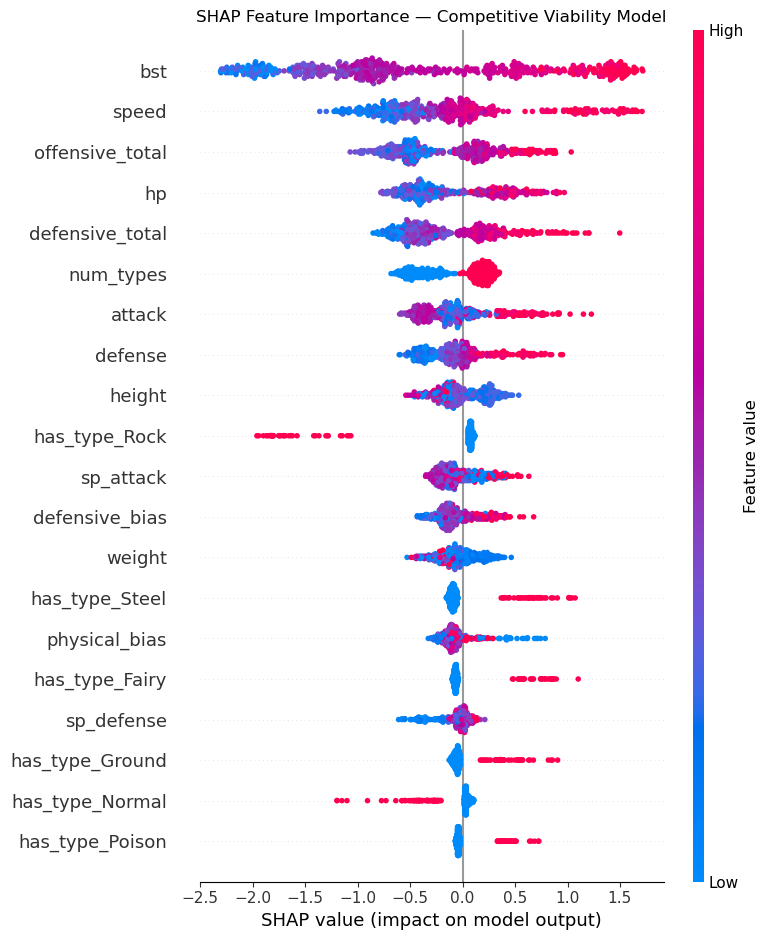

SHAP summary plot saved.


In [14]:
import matplotlib.pyplot as plt

# Summary plot — shows feature importance AND direction of effect
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_train,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False,
)
plt.title("SHAP Feature Importance — Competitive Viability Model")
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved.")

In [15]:
# Pick a well-known viable Pokémon from test set to explain
test_pokemon = df_model[test_mask].copy()
test_pokemon['predicted_prob'] = y_prob
test_pokemon['predicted'] = (y_prob >= 0.35).astype(int)

# Show all Gen 8 predictions
print("Gen 8 predictions:")
print(test_pokemon[['name', 'tier', 'is_viable', 
                     'predicted_prob', 'predicted']]
      .sort_values('predicted_prob', ascending=False)
      .head(20)
      .to_string())

Gen 8 predictions:
             name  tier  is_viable  predicted_prob  predicted
1058    Eternatus  Uber          1        0.981686          1
1052    Dragapult    OU          1        0.969290          1
1066    Spectrier  Uber          1        0.956715          1
1062       Zarude    RU          0        0.951457          1
979      Inteleon    NU          0        0.838732          1
973     Rillaboom    OU          1        0.814759          1
1063    Regieleki    OU          1        0.809921          1
1065    Glastrier    NU          0        0.759919          1
976     Cinderace  Uber          1        0.750625          1
1049    Duraludon    NU          0        0.698738          1
1024    Obstagoon    RU          0        0.629425          1
1023   Grimmsnarl    UU          1        0.602562          1
1027   Sirfetch'd    NU          0        0.591592          1
1064    Regidrago    RU          0        0.524254          1
1068      Calyrex    ZU          0        0.490192 

In [16]:
from src.model import load_model, predict_viability, build_feature_row, get_top_shap_features

# Load model
model_data = load_model()
print(f"Model loaded — ROC-AUC: {model_data['roc_auc']}")

# Test with a known viable Pokémon — Garchomp's stats
garchomp_row = build_feature_row(
    hp=108, attack=130, defense=95,
    sp_attack=80, sp_defense=85, speed=102,
    type_1='Dragon', type_2='Ground',
    is_legendary=False,
    height=1.9, weight=95.0,
)

result = predict_viability(garchomp_row, model_data)
print(f"\nGarchomp prediction:")
print(f"  Viable: {result['viable']}")
print(f"  Probability: {result['probability']:.3f}")

top_features = get_top_shap_features(
    result['shap_values'],
    result['feature_names'],
    n=10
)
print(f"\nTop 10 SHAP features for Garchomp:")
print(top_features[['feature', 'shap_value', 'direction']].to_string())

Model loaded — ROC-AUC: 0.932

Garchomp prediction:
  Viable: True
  Probability: 0.975

Top 10 SHAP features for Garchomp:
           feature  shap_value direction
0              bst    1.464664  Positive
1           attack    0.647366  Positive
2  has_type_Ground    0.387330  Positive
3            speed    0.387053  Positive
4  offensive_total    0.361347  Positive
5               hp    0.355242  Positive
6        sp_attack   -0.166559  Negative
7           height   -0.159260  Negative
8  defensive_total    0.120877  Positive
9       sp_defense   -0.112427  Negative
